# Q. Analytical Derivation

Consider the filter model
\begin{align*}
x^{-}_k &= A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}, \\
y^{-}_k &= H_k\,x^{-}_k + z_k,
\end{align*}
where
$$x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1}),$$

Answer the followings:

1. Show that
$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-),$$
where
$$m_k^- = A_{k-1}m_{k-1},$$
and
$$
P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T.
$$

2. Show that
$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m).$$

3. Show that
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right).$$

4. Show that
$$x^{+}_k\triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k),$$
where the updated mean $m_k$ and updated covariance $P_k$ are given by:
\begin{align*}
K_k &\triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}, \\
m_k &= m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-), \\
P_k &= (I - K_k H_k) P_k^-.
\end{align*}

5. Find
$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}]$  and
$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$.

## Analytical Derivation of the Kalman Filter Steps

### Assumptions and Definitions
We assume that the process noise $w_{k-1}$ and measurement noise $z_k$ are zero-mean, independent Gaussian white noise processes:
* $w_{k-1} \sim \mathscr{N}(0, \Sigma_p)$
* $z_k \sim \mathscr{N}(0, \Sigma_m)$
* $x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1})$ is independent of $w_{k-1}$ and $z_k$.

---

### 1. Prior State Distribution $x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$

The state prediction equation is a linear combination of independent Gaussian random variables:
$$x^{-}_k = A_{k-1}x^{+}_{k-1} + G_{k-1}w_{k-1}$$

Since a linear transformation of Gaussian variables remains Gaussian, $x_k^-$ is Gaussian. Let's find its mean and covariance.

**Mean ($m_k^-$):**
$$\begin{aligned}
m_k^- = \mathbb{E}[x^{-}_k] &= \mathbb{E}[A_{k-1}x^{+}_{k-1} + G_{k-1}w_{k-1}] \\
&= A_{k-1}\mathbb{E}[x^{+}_{k-1}] + G_{k-1}\mathbb{E}[w_{k-1}] \\
&= A_{k-1}m_{k-1} + G_{k-1}(0) \\
&= A_{k-1}m_{k-1}
\end{aligned}$$

**Covariance ($P_k^-$):**
$$\begin{aligned}
P_k^- &= \text{Var}(x^{-}_k) = \mathbb{E}[(x^{-}_k - m_k^-)(x^{-}_k - m_k^-)^T] \\
&= \mathbb{E}\left[\left(A_{k-1}(x^{+}_{k-1} - m_{k-1}) + G_{k-1}w_{k-1}\right)\left(A_{k-1}(x^{+}_{k-1} - m_{k-1}) + G_{k-1}w_{k-1}\right)^T\right]
\end{aligned}$$

Since $x^{+}_{k-1}$ and $w_{k-1}$ are uncorrelated, the cross-terms vanish:
$$\begin{aligned}
P_k^- &= A_{k-1}\mathbb{E}[(x^{+}_{k-1} - m_{k-1})(x^{+}_{k-1} - m_{k-1})^T]A_{k-1}^T + G_{k-1}\mathbb{E}[w_{k-1}w_{k-1}^T]G_{k-1}^T \\
&= A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T
\end{aligned}$$

---

### 2. Prior Measurement Distribution $y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$

The measurement equation is given by:
$$y^{-}_k = H_k x^{-}_k + z_k$$

**Mean:**
$$\begin{aligned}
\mathbb{E}[y^{-}_k] &= \mathbb{E}[H_k x^{-}_k + z_k] \\
&= H_k \mathbb{E}[x^{-}_k] + \mathbb{E}[z_k] \\
&= H_k m_k^-
\end{aligned}$$

**Covariance:**
$$\begin{aligned}
\text{Var}(y^{-}_k) &= \mathbb{E}[(y^{-}_k - H_k m_k^-)(y^{-}_k - H_k m_k^-)^T] \\
&= \mathbb{E}\left[\left(H_k(x^{-}_k - m_k^-) + z_k\right)\left(H_k(x^{-}_k - m_k^-) + z_k\right)^T\right]
\end{aligned}$$

Since $x^{-}_k$ and $z_k$ are uncorrelated, the cross-terms vanish:
$$\begin{aligned}
\text{Var}(y^{-}_k) &= H_k \mathbb{E}[(x^{-}_k - m_k^-)(x^{-}_k - m_k^-)^T]H_k^T + \mathbb{E}[z_k z_k^T] \\
&= H_k P_k^- H_k^T + \Sigma_m
\end{aligned}$$

---

### 3. Joint Distribution of State and Measurement

We want to find the joint Gaussian distribution:
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} \Sigma_{xx} & \Sigma_{xy} \\ \Sigma_{yx} & \Sigma_{yy} \end{bmatrix}
\right)$$

From previous steps, we already know $\Sigma_{xx} = P_k^-$ and $\Sigma_{yy} = H_k P_k^- H_k^T + \Sigma_m$. We only need the cross-covariance term $\Sigma_{xy}$:
$$\begin{aligned}
\Sigma_{xy} = \text{Cov}(x_k^-, y_k^-) &= \mathbb{E}[(x_k^- - m_k^-)(y_k^- - H_k m_k^-)^T] \\
&= \mathbb{E}\left[(x_k^- - m_k^-)\left(H_k(x_k^- - m_k^-) + z_k\right)^T\right] \\
&= \mathbb{E}[(x_k^- - m_k^-)(x_k^- - m_k^-)^T]H_k^T + \mathbb{E}[(x_k^- - m_k^-)z_k^T]
\end{aligned}$$

Because $x_k^-$ and $z_k$ are independent, $\mathbb{E}[(x_k^- - m_k^-)z_k^T] = 0$. Thus:
$$\Sigma_{xy} = P_k^- H_k^T$$
$$\Sigma_{yx} = \Sigma_{xy}^T = H_k P_k^-$$

Putting it all together:
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right)$$

---

### 4 & 5. Posterior State Distribution (Conditional Distribution)

To find $x^{+}_k \triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$, we use the **Gaussian Conditioning Theorem**.

If a joint distribution is given by:
$$\begin{bmatrix} X \\ Y \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} \mu_x \\ \mu_y \end{bmatrix},
\begin{bmatrix} \Sigma_{xx} & \Sigma_{xy} \\ \Sigma_{yx} & \Sigma_{yy} \end{bmatrix}
\right)$$

Then the conditional distribution $(X \mid Y = y)$ is Gaussian with:
$$\mathbb{E}[X \mid Y = y] = \mu_x + \Sigma_{xy} \Sigma_{yy}^{-1} (y - \mu_y)$$
$$\text{Var}(X \mid Y = y) = \Sigma_{xx} - \Sigma_{xy} \Sigma_{yy}^{-1} \Sigma_{yx}$$

Substituting our joint matrix elements where $X = x_k^-$ and $Y = y_k^-$:

#### Defining the Kalman Gain ($K_k$)
$$K_k \triangleq \Sigma_{xy} \Sigma_{yy}^{-1} = P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$$

#### Conditional Mean Formulation (Answers to Q4 and Q5 Mean)
$$\begin{aligned}
m_k = \mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}] &= m_k^- + \Sigma_{xy} \Sigma_{yy}^{-1} (y^{\mathrm{obs}}_{k} - H_k m_k^-) \\
&= m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-)
\end{aligned}$$

#### Conditional Covariance Formulation (Answers to Q4 and Q5 Variance)
$$\begin{aligned}
P_k = \text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) &= \Sigma_{xx} - \Sigma_{xy} \Sigma_{yy}^{-1} \Sigma_{yx} \\
&= P_k^- - K_k (H_k P_k^-) \\
&= (I - K_k H_k) P_k^-
\end{aligned}$$

Thus, the updated state follows:
$$x^{+}_k \sim \mathscr{N}(m_k, P_k)$$

# Q. 1-D Example

Consider the scalar linear-Gaussian filter model
\begin{aligned}
x^-_k &= a\,x^+_{k-1} + w_{k-1},\qquad w_{k-1}\sim\mathscr N(0,q),\\
y^-_k &= h\,x^-_k + z_k,\qquad\;\;\;\; z_k\sim\mathscr N(0,r),
\end{aligned}
with prior $x_0\sim \mathscr{N}(m_0,P_0)$. Define $Y_{k}=\{y^{\mathrm{obs}}_1,\dots,y^{\mathrm{obs}}_{k}\}$.

Answer the following:

1. Show that
\begin{aligned}
m_k^- &= a\,m_{k-1},\\
P_k^- &= a^2 P_{k-1} + q.
\end{aligned}

2. Show that
\begin{aligned}
m_k &= m_k^- + K_k\,v_k
= m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr),\\
P_k &= (1 - K_k h)\,P_k^-
= \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^- .
\end{aligned}

3. Show that the predictive measurement distribution (before seeing $y_k$):
\begin{align*}
p(y^-_k | Y_{k-1})=\mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr).
\end{align*}

4. Show that the posterior-predictive measurement distribution (after filtering on $y_k$):
\begin{align*}
p(y^-_k\mid Y_k)=\mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr).
\end{align*}

5. For suitable numerical values for $a,q,h,r$ animate the above to prior distribution and the posterior distribution.

## 1-D Scalar Kalman Filter Derivation

### 1. Prior State Distribution (Time Update Step)
Given the scalar state transition equation:
$$x^-_k = a\,x^+_{k-1} + w_{k-1}$$
where $x^+_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1})$ and $w_{k-1} \sim \mathscr{N}(0, q)$.

**Mean ($m_k^-$):**
$$\begin{aligned}
m_k^- = \mathbb{E}[x^-_k] &= \mathbb{E}[a\,x^+_{k-1} + w_{k-1}] \\
&= a\,\mathbb{E}[x^+_{k-1}] + \mathbb{E}[w_{k-1}] \\
&= a\,m_{k-1}
\end{aligned}$$

**Covariance ($P_k^-$):**
$$\begin{aligned}
P_k^- = \text{Var}(x^-_k) &= \text{Var}(a\,x^+_{k-1} + w_{k-1})
\end{aligned}$$
Since the previous state $x^+_{k-1}$ and process noise $w_{k-1}$ are independent, the variances simply add up (with the scalar coefficient squared):
$$\begin{aligned}
P_k^- &= a^2 \text{Var}(x^+_{k-1}) + \text{Var}(w_{k-1}) \\
&= a^2 P_{k-1} + q
\end{aligned}$$

---

### 2. Posterior State Update (Measurement Update Step)
From the general Kalman filter equations applied to the 1-D scalar case, the measurement residual covariance $S_k$ and Kalman gain $K_k$ are:
$$S_k = h^2 P_k^- + r$$
$$K_k = \frac{P_k^- h}{S_k} = \frac{P_k^- h}{h^2 P_k^- + r}$$

**Updated Mean ($m_k$):**
Defining the measurement residual (innovation) as $v_k = y^{\mathrm{obs}}_k - h\,m_k^-$, the updated mean is:
$$\begin{aligned}
m_k &= m_k^- + K_k\,v_k \\
&= m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr)
\end{aligned}$$

**Updated Covariance ($P_k$):**
$$\begin{aligned}
P_k &= (1 - K_k h)\,P_k^- \\
&= \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^-
\end{aligned}$$

---

### 3. Predictive Measurement Distribution: $p(y^-_k \mid Y_{k-1})$
This is the distribution of the measurement $y^-_k$ *before* observing its actual value, conditioned on all historical data up to step $k-1$.

The measurement model is:
$$y^-_k = h\,x^-_k + z_k$$
where $x^-_k \mid Y_{k-1} \sim \mathscr{N}(m_k^-, P_k^-)$ and $z_k \sim \mathscr{N}(0, r)$.

**Mean:**
$$\mathbb{E}[y^-_k \mid Y_{k-1}] = h\,\mathbb{E}[x^-_k \mid Y_{k-1}] + \mathbb{E}[z_k] = h\,m_k^-$$

**Covariance:**
$$\text{Var}(y^-_k \mid Y_{k-1}) = h^2 \text{Var}(x^-_k \mid Y_{k-1}) + \text{Var}(z_k) = h^2 P_k^- + r$$

Thus, the distribution is Gaussian:
$$p(y^-_k \mid Y_{k-1}) = \mathscr{N}\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr)$$

---

### 4. Posterior-Predictive Measurement Distribution: $p(y^-_k \mid Y_k)$
This represents our updated belief about what the sensor *should* have read at step $k$, evaluated *after* we have already factored the observation $y^\mathrm{obs}_k$ into our state estimate ($x^+_k \sim \mathscr{N}(m_k, P_k)$).

Using the measurement equation mapped from the filtered state:
$$y^-_k = h\,x^+_k + z_k$$

**Mean:**
$$\mathbb{E}[y^-_k \mid Y_k] = h\,\mathbb{E}[x^+_k \mid Y_k] + \mathbb{E}[z_k] = h\,m_k$$

**Covariance:**
$$\text{Var}(y^-_k \mid Y_k) = h^2 \text{Var}(x^+_k \mid Y_k) + \text{Var}(z_k) = h^2 P_k + r$$

Thus, the distribution is:
$$p(y^-_k \mid Y_k) = \mathscr{N}\bigl(h\,m_k,\; h^2 P_k + r\bigr)$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.stats import norm
from IPython.display import HTML

# --- 1. Simulation Parameters ---
np.random.seed(42)
N_steps = 20
a = 0.95    # State transition
q = 0.2     # Process noise variance
h = 1.0     # Measurement matrix
r = 0.5     # Measurement noise variance

# True initial state and prior parameters
x_true = 0.0
m = 0.0
P = 2.0

# Pre-allocate arrays to log history for animation
history = []

# --- 2. Filter Loop ---
for k in range(N_steps):
    # Process Dynamics
    w = np.random.normal(0, np.sqrt(q))
    x_true = a * x_true + w

    # Measurement Generation
    z = np.random.normal(0, np.sqrt(r))
    y_obs = h * x_true + z

    # Time Update (Predict)
    m_prior = a * m
    P_prior = a**2 * P + q

    # Measurement Update (Correct)
    S = h**2 * P_prior + r
    K = (P_prior * h) / S
    m_post = m_prior + K * (y_obs - h * m_prior)
    P_post = (1 - K * h) * P_prior

    # Store snapshot for visualization
    history.append({
        'step': k, 'x_true': x_true, 'y_obs': y_obs,
        'm_prior': m_prior, 'P_prior': P_prior,
        'm_post': m_post, 'P_post': P_post
    })

    # Update states for next iteration
    m, P = m_post, P_post

# --- 3. Animation Setup ---
fig, ax = plt.subplots(figsize=(10, 6))
x_axis = np.linspace(-5, 5, 500)

def update(frame):
    ax.clear()
    data = history[frame]

    # Compute PDF curves
    prior_pdf = norm.pdf(x_axis, data['m_prior'], np.sqrt(data['P_prior']))
    post_pdf = norm.pdf(x_axis, data['m_post'], np.sqrt(data['P_post']))

    # Plotting distributions
    ax.plot(x_axis, prior_pdf, 'r-', lw=2, label=f"Prior (Predictive): $\mu={data['m_prior']:.2f}, \sigma^2={data['P_prior']:.2f}$")
    ax.fill_between(x_axis, prior_pdf, color='red', alpha=0.15)

    ax.plot(x_axis, post_pdf, 'b-', lw=2, label=f"Posterior (Filtered): $\mu={data['m_post']:.2f}, \sigma^2={data['P_post']:.2f}$")
    ax.fill_between(x_axis, post_pdf, color='blue', alpha=0.15)

    # Plot ground truth and observation
    ax.axvline(data['x_true'], color='black', linestyle='--', lw=2, label=f"True State ($x_k$): {data['x_true']:.2f}")
    ax.scatter(data['y_obs'], 0.02, color='green', marker='X', s=150, zorder=5, label=f"Observed ($y_k$): {data['y_obs']:.2f}")

    ax.set_title(f"1-D Kalman Filter Simulation: Step {frame+1}/{N_steps}", fontsize=14)
    ax.set_xlabel("State Space ($x$)", fontsize=12)
    ax.set_ylabel("Probability Density", fontsize=12)
    ax.set_ylim(0, 1.2)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

# Generate and display the HTML5 video animation inside Colab
anim = FuncAnimation(fig, update, frames=N_steps, interval=1200, repeat=False)
plt.close()
HTML(anim.to_html5_video())

<>:66: SyntaxWarning: invalid escape sequence '\m'
<>:66: SyntaxWarning: invalid escape sequence '\s'
<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:69: SyntaxWarning: invalid escape sequence '\s'
<>:66: SyntaxWarning: invalid escape sequence '\m'
<>:66: SyntaxWarning: invalid escape sequence '\s'
<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:69: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6544/1960149921.py:66: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(x_axis, prior_pdf, 'r-', lw=2, label=f"Prior (Predictive): $\mu={data['m_prior']:.2f}, \sigma^2={data['P_prior']:.2f}$")
/tmp/ipykernel_6544/1960149921.py:66: SyntaxWarning: invalid escape sequence '\s'
  ax.plot(x_axis, prior_pdf, 'r-', lw=2, label=f"Prior (Predictive): $\mu={data['m_prior']:.2f}, \sigma^2={data['P_prior']:.2f}$")
/tmp/ipykernel_6544/1960149921.py:69: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(x_axis, post_pdf, 'b-', lw=2, label=f"Posterior (Filtered): $\mu={data['m_

# Q. 2D-Position Estimation

## Part A

Consider a two-dimensional constant-velocity dynamical system. The hidden state at time step $k$ is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where $(p_x(k),p_y(k))$ denote the position components and $(v_x(k),v_y(k))$ denote the velocity components.

The measurement consists only of the two position components:

$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The linear Gaussian state-space filter model is

$$
x^-_k = A x^+_{k-1} + G w_{k-1},
$$

$$
y^-_k = Hx^+_k + z_k,
$$

where

$$
w_{k-1} \sim \mathscr{N}(0,\Sigma_p),
\qquad
z_k \sim \mathscr{N}(0,\Sigma_m).
$$

The process noise sequence $w_k$, measurement noise sequence $z_k$, and the initial state are assumed mutually independent.

Show that:

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
$$



$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
$$

and

$$
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

## Derivation of State-Space Matrices for 2D Position Estimation

### 1. State Transition Matrix ($A$) and Noise Gain Matrix ($G$)

A constant-velocity model assumes that acceleration is treated as process noise. Let $a_x(t)$ and $a_y(t)$ be the unknown acceleration components modeled as continuous white noise.

Using standard kinematic equations over a discrete time step $\Delta t$, the position and velocity components evolve as follows:

$$
\begin{aligned}
p_x(k) &= p_x(k-1) + v_x(k-1)\Delta t + \frac{1}{2}a_x(k-1)\Delta t^2 \\
p_y(k) &= p_y(k-1) + v_y(k-1)\Delta t + \frac{1}{2}a_y(k-1)\Delta t^2 \\
v_x(k) &= v_x(k-1) + a_x(k-1)\Delta t \\
v_y(k) &= v_y(k-1) + a_y(k-1)\Delta t
\end{aligned}
$$

We can express this system of linear equations in matrix-vector form by separating the deterministic state components from the random acceleration noise vector $w_{k-1} = \begin{bmatrix} a_x(k-1) \\ a_y(k-1) \end{bmatrix}$:

$$
\begin{bmatrix}
p_x(k) \\
p_y(k) \\
v_x(k) \\
v_y(k)
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & \Delta t & 0 \\
0 & 1 & 0 & \Delta t \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
p_x(k-1) \\
p_y(k-1) \\
v_x(k-1) \\
v_y(k-1)
\end{bmatrix}
+
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0 \\
0 & \frac{1}{2}\Delta t^2 \\
\Delta t & 0 \\
0 & \Delta t
\end{bmatrix}
\begin{bmatrix}
a_x(k-1) \\
a_y(k-1)
\end{bmatrix}
$$

Comparing this directly with the linear filter state equation $x^-_k = A x^+_{k-1} + G w_{k-1}$, we find:

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
\qquad
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}
$$

---

### 2. Measurement Matrix ($H$)

The measurement vector $y_k$ captures only the two position components from the state vector $x_k$. The explicit measurement equations are:

$$
\begin{aligned}
p_x^{\mathrm{meas}}(k) &= 1 \cdot p_x(k) + 0 \cdot p_y(k) + 0 \cdot v_x(k) + 0 \cdot v_y(k) + z_{x,k} \\
p_y^{\mathrm{meas}}(k) &= 0 \cdot p_x(k) + 1 \cdot p_y(k) + 0 \cdot v_x(k) + 0 \cdot v_y(k) + z_{y,k}
\end{aligned}
$$

Writing these equations in matrix form yields:

$$
\begin{bmatrix}
p_x^{\mathrm{meas}}(k) \\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0
\end{bmatrix}
\begin{bmatrix}
p_x(k) \\
p_y(k) \\
v_x(k) \\
v_y(k)
\end{bmatrix}
+
\begin{bmatrix}
z_{x,k} \\
z_{y,k}
\end{bmatrix}
$$

Comparing this to the measurement update structure $y^-_k = H x^+_k + z_k$, we match terms to conclude:

$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix}
$$

## Part B

Develop a python based method to filter a sequence of noisy GPS obtained position meaurements.

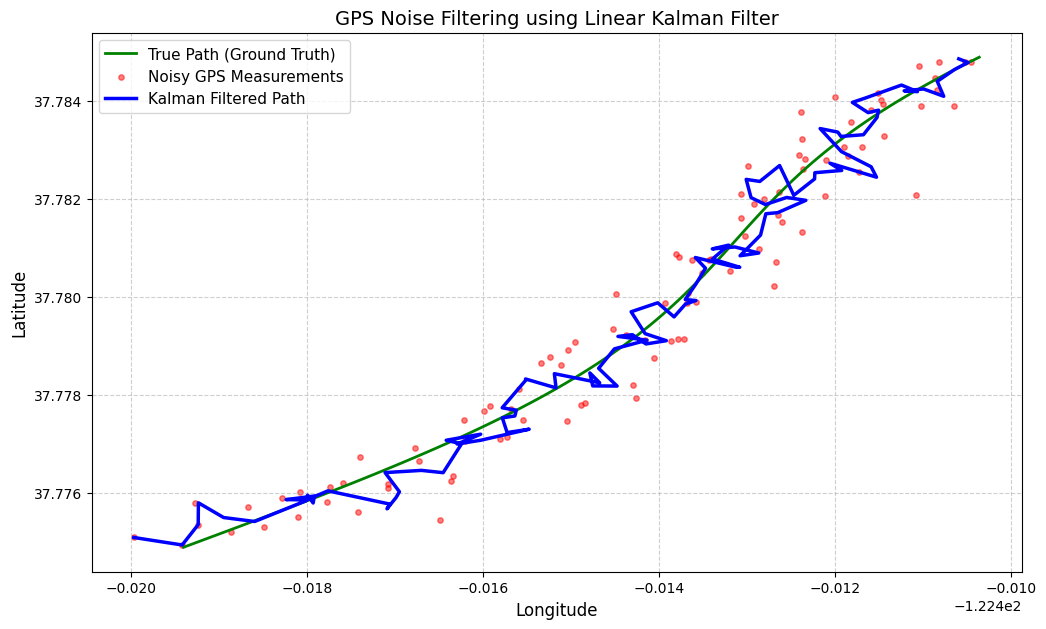

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. KALMAN FILTER CLASS DEFINITION
# ==========================================
class GPSKalmanFilter:
    def __init__(self, dt=1.0, process_noise=1e-5, measurement_noise=1e-4):
        """
        State vector x = [lat, lon, v_lat, v_lon]'
        dt: Time step between measurements
        """
        self.dt = dt

        # State transition matrix (predicts next state based on constant velocity)
        self.F = np.array([
            [1, 0, dt,  0],
            [0, 1,  0, dt],
            [0, 0,  1,  0],
            [0, 0,  0,  1]
        ])

        # Measurement matrix (we only observe position: lat, lon)
        self.H = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]
        ])

        # Process noise covariance (how much we trust our movement model)
        self.Q = np.eye(4) * process_noise

        # Measurement noise covariance (how much we trust the GPS sensor)
        self.R = np.eye(2) * measurement_noise

        # Initialize state covariance matrix (uncertainty)
        self.P = np.eye(4) * 1.0

        # Initialize state estimate
        self.x = None

    def initialize(self, init_lat, init_lon):
        """Initialize the filter with the first GPS reading."""
        self.x = np.array([[init_lat], [init_lon], [0.0], [0.0]])

    def update(self, measured_lat, measured_lon):
        """Performs the Predict and Update steps of the Kalman Filter."""
        if self.x is None:
            self.initialize(measured_lat, measured_lon)
            return self.x[0, 0], self.x[1, 0]

        # ----------------------------------
        # PREDICT STEP
        # ----------------------------------
        self.x = np.dot(self.F, self.x)
        self.P = np.dot(np.dot(self.F, self.P), self.F.T) + self.Q

        # ----------------------------------
        # UPDATE STEP (Correct with measurement)
        # ----------------------------------
        z = np.array([[measured_lat], [measured_lon]]) # Measurement vector
        y = z - np.dot(self.H, self.x)                  # Innovation (residual)

        # Kalman Gain calculation
        S = np.dot(np.dot(self.H, self.P), self.H.T) + self.R
        K = np.dot(np.dot(self.P, self.H.T), np.linalg.inv(S))

        # Update state and covariance
        self.x = self.x + np.dot(K, y)
        self.P = self.P - np.dot(np.dot(K, self.H), self.P)

        return self.x[0, 0], self.x[1, 0]


# ==========================================
# 2. GENERATE SIMULATED NOISY GPS DATA
# ==========================================
np.random.seed(42)  # For reproducible results
num_steps = 100
dt = 1.0

# True path (e.g., a vehicle moving linearly with a slight curve)
true_lat = np.linspace(37.7749, 37.7849, num_steps)
true_lon = np.linspace(-122.4194, -122.4094, num_steps) + 0.001 * np.sin(np.linspace(0, 5, num_steps))

# Add Gaussian noise to simulate messy GPS data
noise_std = 0.0004
noisy_lat = true_lat + np.random.normal(0, noise_std, num_steps)
noisy_lon = true_lon + np.random.normal(0, noise_std, num_steps)


# ==========================================
# 3. RUN THE KALMAN FILTER
# ==========================================
# Tune process_noise down if your true path is very smooth.
# Tune measurement_noise up if your GPS is incredibly jumpy.
kf = GPSKalmanFilter(dt=dt, process_noise=1e-8, measurement_noise=2e-7)

filtered_lat = []
filtered_lon = []

for lat, lon in zip(noisy_lat, noisy_lon):
    f_lat, f_lon = kf.update(lat, lon)
    filtered_lat.append(f_lat)
    filtered_lon.append(f_lon)


# ==========================================
# 4. PLOT THE RESULTS
# ==========================================
plt.figure(figsize=(12, 7))
plt.plot(true_lon, true_lat, 'g-', label='True Path (Ground Truth)', linewidth=2)
plt.scatter(noisy_lon, noisy_lat, color='red', alpha=0.5, s=15, label='Noisy GPS Measurements')
plt.plot(filtered_lon, filtered_lat, 'b-', label='Kalman Filtered Path', linewidth=2.5)

plt.title('GPS Noise Filtering using Linear Kalman Filter', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()